In [1]:
import os
import yaml
import re
import torch
import numpy as np
import pandas as pd
import pandas as pd
import networkx as nx
from utils import utils
from types import SimpleNamespace
from datetime import datetime
import matplotlib.pyplot as plt
import torch_geometric as pyg
from Data.base_data import Merge_PygDataset,Function_group_PygDataset,Spectrum_PygDataset
from Graph_process import Merge_GraphText
from Graph_process import extend_one_shot
from Models.models import PyGRGCNEdge,BinGraphModel,BinGraphAttModel

bin C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\bitsandbytes\libbitsandbytes_cuda116.dll


In [2]:
def pd_format(source):
    format_dataframe = pd.DataFrame(columns=['Type', 'Subtype', 'Functional group', 'Absorb', 'Range', 'S-Strength'])
    for i in range(len(source)):
        # 将df1的每一行数据输入到format_df中，进行相应的格式化
        format_dataframe.loc[i,'Type'] = source.loc[i,'Key1(大类物质)'] # 烃类
        format_dataframe.loc[i,'Subtype'] = source.loc[i,'Key2(子类物质)'] # 烯烃
        if source.loc[i,'Key3(官能团名)'] != source.loc[i,'Key2(子类物质)'] :
            #format_df.loc[i,'Functional group'] = 'feature node. Functional group: <{}>.'.format(supplement_data.loc[i,'Key3(官能团名)'])
            format_dataframe.loc[i,'Functional group'] = source.loc[i,'Key3(官能团名)']
        else:
            format_dataframe.loc[i,'Functional group'] = None
        if source.loc[i,'Key4(子结构/振动类型)'] != source.loc[i,'Key3(官能团名)'] :
            format_dataframe.loc[i,'Absorb'] = 'feature node. Absorbtion: <{}>'.format(source.loc[i,'Key4(子结构/振动类型)'])
        else:
            format_dataframe.loc[i,'Absorb'] = None
        format_dataframe.loc[i,'Range'] = 'feature node.Range: <{}>'.format(source.loc[i,'范围'])
        format_dataframe.loc[i,'S-Strength'] = 'feature node.S-Strength: <{}>'.format(source.loc[i,'强度'])
    
    return format_dataframe

def get_logic_label(ordered_txt):
    or_labeled_text = []
    not_and_labeled_text = []
    for i in range(len(ordered_txt)):
        for j in range(len(ordered_txt)):
            c1 = ordered_txt[i]
            c2 = ordered_txt[j]
            txt = "prompt node. Sample category and description: not " + c1[0] + ". " + c1[1][0] + " and not " + c2[
                0] + ". " + c2[1][0]
            not_and_labeled_text.append(txt)
            txt = "prompt node. Sample category and description: either " + c1[0] + ". " + c1[1][0] + " or " + c2[
                0] + ". " + c2[1][0]
            or_labeled_text.append(txt)
    return or_labeled_text + not_and_labeled_text

# 加载化学知识图谱

## 加载元素信息，加载官能团信息

In [3]:
# 加载信息
Function_information_loader = Function_group_PygDataset()
FGD = Function_information_loader.data_loader('.\Datasets\Knowledge graph(chemistry)\knowledge_graph.gexf','graph')

## 加载官能团振动吸收信息

In [4]:
# 进行预处理
supplement_data = pd.read_excel('.\Datasets\Functional group (chemistry)\Functional_group_data_from_wiki_format.xlsx')

### 格式化信息

In [5]:
format_df = pd_format(supplement_data)

## 混合以上两个图谱，生成完整的化学信息知识图谱

In [6]:
# 图数据：FGD.data['1']['Data']
G = FGD.data['1']['Data'].copy()
# 给G添加复数节点：节点的名称为'Functional group{}';可能存在的振动节点；光谱范围节点
# 加入relation关系 ，has'range'
# {}为自然数列，从1开始，每个节点包含'raw_text'和'color'两个属性".
Append_node = []
Append_edge = []
for i in range(len(format_df)):
    # 检测该节点是否存在
    Subtype = ('#' + format_df.loc[i,'Subtype']).replace(' ','')
    core = ''

    dictionary_node = []
    dictionary_edge = []

    G.add_node(f'Range{i+1}',raw_text = format_df.iloc[i]['Range'],color = 'purple')
    dictionary_node.append(format_df.iloc[i]['Range'])
    G.add_node(f'S-Strength{i+1}',raw_text = format_df.iloc[i]['S-Strength'],color = 'yellow')
    dictionary_node.append(format_df.iloc[i]['S-Strength'])

    if format_df.iloc[i]['Functional group']!=None:
        core = ('#' + format_df.loc[i,'Functional group']).replace(' ','')
    else:
        core = Subtype
    if core not in G.nodes:
        G.add_node(core,raw_text = 'feature node. Functional group: <{}>.'.format(core),color = 'cyan')
    else:# 给节点core添加属性
        G.nodes[core]['raw_text'] = 'feature node. Functional group: <{}>.'.format(core)
        G.nodes[core]['color'] = 'cyan'
    if not G.has_edge(core,Subtype):
        G.add_edge(core,Subtype,relation='http://www.w3.org/1999/02/22-rdf-syntax-ns#type',id='2736')
            
    # else:# 给节点core添加属性
    #     G.nodes[core]['raw_text'] = 'feature node. Functional group: <{}>.'.format(core)
    #     G.nodes[core]['color'] = 'cyan'
    dictionary_node.append(core)

    # if format_df.iloc[i]['Functional group'] not in G.nodes and format_df.iloc[i]['Functional group']!=None: # 如果有特定的官能团描述，则使用这个描述
    #     core = '#' + format_df.loc[i,'Functional group']
    #     G.add_node(core,raw_text = 'feature node. Functional group: <{}>.'.format(core),color = 'cyan')
    #     core = format_df.iloc[i]['Functional group']  
    # elif format_df.iloc[i]['Functional group'] in G.nodes and format_df.iloc[i]['Functional group']!=None:
    #     core = format_df.iloc[i]['Functional group']
    # else:core = Subtype
    # dictionary_node.append(core)

    if not G.has_edge(core,f'Range{i+1}'):
        G.add_edge(core,f'Range{i+1}',relation='has_range')
        dictionary_edge.append('FP-Ran')
    if not G.has_edge(f'Range{i+1}',f'S-Strength{i+1}'):
        G.add_edge(f'Range{i+1}',f'S-Strength{i+1}',relation='has_strength')
        dictionary_edge.append('Ran-Str')

    if format_df.iloc[i]['Absorb']!=None and format_df.iloc[i]['Absorb'] not in G.nodes:
        G.add_node(format_df.iloc[i]['Absorb'],raw_text = format_df.iloc[i]['Absorb'],color = 'yellow')
        dictionary_node.append(format_df.iloc[i]['Absorb'])
        if not G.has_edge(f'Range{i+1}',format_df.iloc[i]['Absorb']):
            G.add_edge(f'Range{i+1}',format_df.iloc[i]['Absorb'],relation='has_absorb')
            dictionary_edge.append('Ran-Ab')
    elif format_df.iloc[i]['Absorb']!=None and format_df.iloc[i]['Absorb'] in G.nodes:
        dictionary_node.append(format_df.iloc[i]['Absorb'])
        if not G.has_edge(f'Range{i+1}',format_df.iloc[i]['Absorb']):
            G.add_edge(f'Range{i+1}',format_df.iloc[i]['Absorb'],relation='has_absorb')
            dictionary_edge.append('Ran-Ab')
    #添加连线
    # 检测连线是否存在
    # if not G.has_edge(core,f'Range{i+1}'):
    #     G.add_edge(core,f'Range{i+1}',relation='has_range')
    #     dictionary_edge.append('FP-Ran')
    # if not G.has_edge(core,f'S-Strength{i+1}'):
    #     G.add_edge(core,f'S-Strength{i+1}',relation='has_strength')
    #     dictionary_edge.append('FP-Str')
    
    Append_node.append(dictionary_node)
    Append_edge.append(dictionary_edge)


In [7]:
# 文本数据图谱构造
#FG_graph = Function_information_loader.construct_graph(dataset,key='3.烯烃的骨架振动')
FG_graph = G
#Function_information_loader.GP 图形类
#Function_information_loader.GP.graph # 图数据

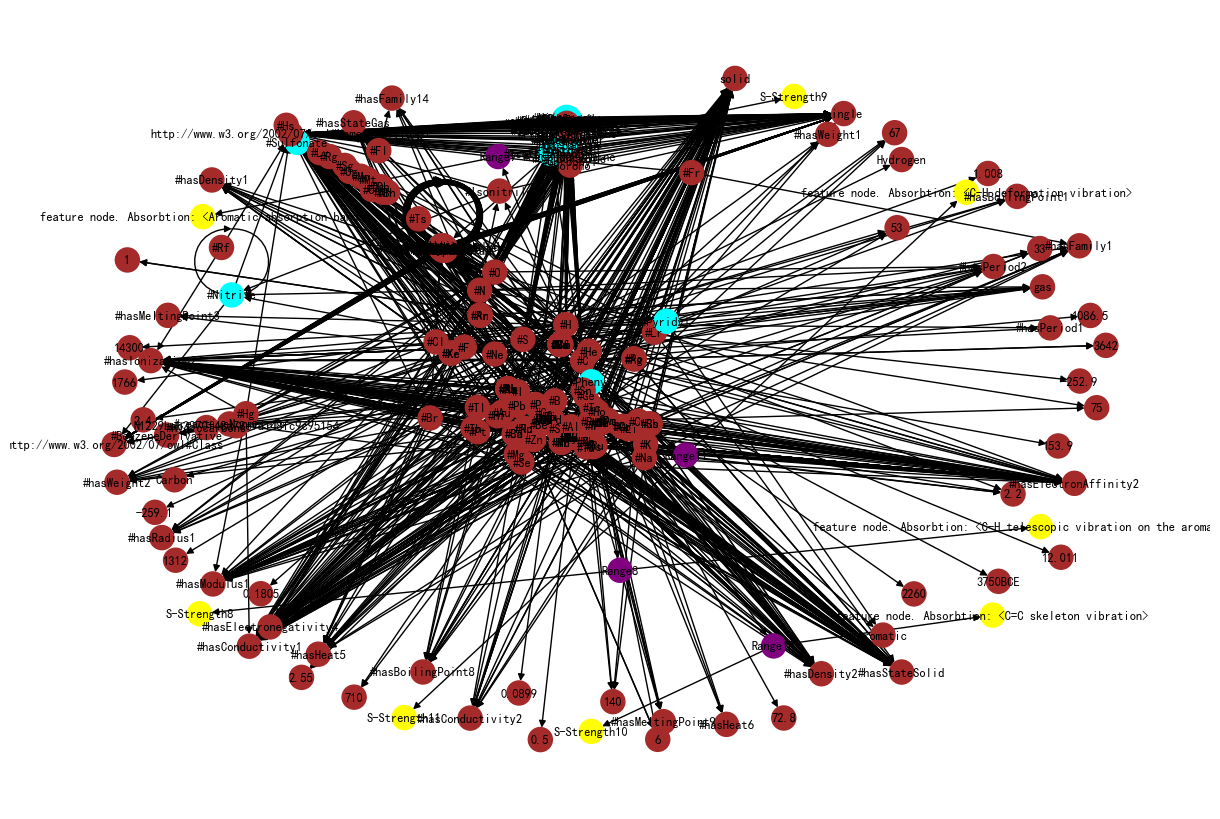

In [8]:
# 展示化学知识子图
# 颜色说明：
# 子类物质名称，如Alkane-烷烃 ——> 棕色
# 官能团名称，如Alkyl-烷基 ——> 青色
# 子结构/振动类型/振动强度，如C-H deformation vibration ——> 黄色
# 吸收区间，如1500-1145 ——> 紫色
# 其余节点，设置为棕色

sub_graph = nx.generators.ego_graph(FG_graph, '#Phenyl', radius=2,undirected=True)
ppp = sub_graph

plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
#colors= [ppp.nodes[n]['color'] for n in ppp.nodes()]
colors = []
for n in ppp.nodes():
    try:colors.append(ppp.nodes[n]['color'])
    except:
        colors.append('brown')
        #print(n)

plt.figure(figsize=(12, 8))
nx.draw(ppp, pos=pos, with_labels=True,font_size=9,node_color=colors)
edge_labels = nx.get_edge_attributes(ppp, 'relatio')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

# 加载样本光谱信息

## 导入样本信息

In [9]:
# 加载光谱信息
Spectrum_loader = Spectrum_PygDataset()
SD = Spectrum_loader.data_loader('G:\Research\数据集\Pper4-Database\Spectral Database')

100%|██████████| 306/306 [00:02<00:00, 130.71it/s]


## 光谱节点化预处理

In [10]:
# 光谱数据预处理
spectrum_dataset = Spectrum_loader.preprocess(SD.data)
#spectrum_dataset['147']['Node']
#Spectrum_loader.pre_data

In [11]:
# 光谱数据图谱构造
Spectrum_graph = Spectrum_loader.construct_graph(spectrum_dataset)

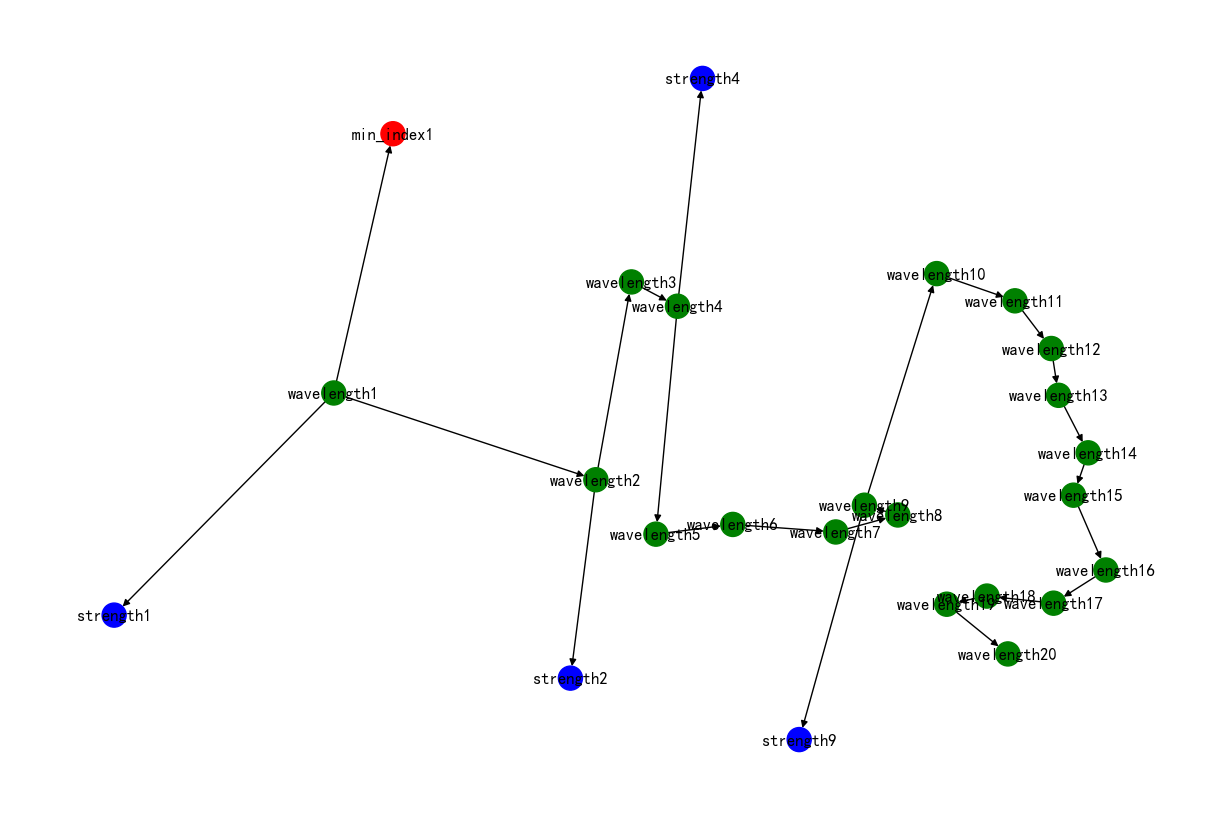

In [12]:
# 图谱可视化
# 颜色说明：
# 波长区间，——> 绿色
# 吸收峰标注及其强度 ——> 蓝色
# 最大吸收位置 ——> 红色

Spectrum_loader.graph_visualisation(Spectrum_graph['(C6H4)2'])

# 混合化学知识图谱与光谱节点图

In [13]:
# Merge_information = Merge_GraphText(FG_graph,Spectrum_graph['(C6H4)2'])
# range_node, wave = Merge_information.get_information(text_graph=FG_graph,)

In [14]:
# 光谱数据预处理
##spectrum_dataset = Spectrum_loader.preprocess(SD.data)
#spectrum_dataset['147']['Node']
#Spectrum_loader.pre_data

In [15]:
# 光谱数据图谱构造
##Spectrum_graph = Spectrum_loader.construct_graph(spectrum_dataset)
#Spectrum_graph
#Spectrum_loader.GP.graph_dataset

In [16]:
# 图谱可视化
##Spectrum_loader.graph_visualisation(Spectrum_graph['(C6H4)2'])

In [13]:
Merge_information = Merge_GraphText(FG_graph,Spectrum_graph['(C6H4)2'])
range_node, wave = Merge_information.get_information(text_graph=FG_graph,)

## 提供官能团的负吸收信息

In [14]:
#SG = Merge_information.spectrum_graph.nodes(data=True)
# 确认不存在的官能团内容
#{'胺，醇':[4000,3200],'炔烃':[3310,3300],'芳香族化合物,烯族':[3100,3000],'异氰酸盐，异氰酸酯，硫氰酸盐，硫氰酸酯，异硫氰酸酯，异硫氰酸盐':[2500,2000],'酯，酮，羧酸，羧酸盐':[1870,1550],'烯族化合物':[1690,1620],'硝酸盐化合物':[1655,1610],'硝基化合物':[1600,1510],'芳环系统':[1600,1450],'硫代氧化物，砜，磺酸酯基':[1420,990]}

non_dict = {'#Amines,#Hydroxyl':[4000,3200],'#Alkynyl':[3310,3300],'#Phenyl,#Alkenyl':[3100,3000],'#Carboalkoxy,#Ketone,#Carboxyl,#Aldehyde':[1870,1550],'#Alkenyl':[1690,1620],'#Nitro':[1600,1510],'#Phenyl,#Pyridyl':[1600,1450],'#Sulfide':[1420,990]}
# 在SG的不同波段节点中，查找以上的官能团是否存在

In [15]:
all_Table,isexist,score_dict = Merge_information.find_no_exist_FG(table=non_dict)
# 评分策略：
# 小于等于0.5的不存在，除非在之前出现过且分数大于0.5

#Amines,#Hydroxyl : 0.25
#Alkynyl : 0.0
#Phenyl,#Alkenyl : 1.0
#Carboalkoxy,#Ketone,#Carboxyl,#Aldehyde : 0.5
#Alkenyl : 1.0
#Nitro : 1.0
#Phenyl,#Pyridyl : 0.5
#Sulfide : 0.5


## 确定光谱中不同的吸收峰可能对应的官能团

In [16]:
######### 输出对应的特征波段信息
for i in wave:
    # 删除i[0]中的'wave'，并与'wavelength'拼接
    index_symbol = i[0]
    print(Spectrum_graph['(C6H4)2'].nodes(data=True)[index_symbol])

{'raw_text': 'Feature Node1. Wavelength: from <600.0> to <894.887898>.(Unit: number of waves)', 'color': 'green'}
{'raw_text': 'Feature Node2. Wavelength: from <895.0059> to <1189.893798>.(Unit: number of waves)', 'color': 'green'}
{'raw_text': 'Feature Node4. Wavelength: from <1485.0177> to <1779.905598>.(Unit: number of waves)', 'color': 'green'}
{'raw_text': 'Feature Node9. Wavelength: from <2960.047201> to <3254.935099>.(Unit: number of waves)', 'color': 'green'}


In [17]:
# 获取连接在不同节点上的可能存在的官能团序列
connected_dict = Merge_information.map_information(range_node, wave)

######### connected_dict对应的官能团信息
for key,value in connected_dict.items():
    print(key)
    for k in value:
        print([i for i in FG_graph.predecessors(k.replace('Functional group','Range'))])
    print('-----------------')

wavelength1
['#Pyridyl']
['#Hydroxyl']
['#fluoro']
['#chloro']
['#Alkenyl']
['#Phenyl']
-----------------
wavelength2
['#Hydroxyl']
['#fluoro']
['#Sulfoxide']
['#Ether']
['#Amines']
['#Carboxyl']
-----------------
wavelength4
['#Carboalkoxy']
['#Pyridyl']
['#Ketone']
['#Phenyl']
['#Nitrosooxy']
['#Alkenyl']
['#Aldehyde']
-----------------
wavelength9
['#Alkenyl']
['#Phenyl']
['#Pyridyl']
-----------------


## 合并光谱图与化学知识图

In [18]:
# 合并图谱
new_graph_method_2 = nx.compose(FG_graph, Spectrum_graph['(C6H4)2'])
######### 节点信息获取
#new_graph_method_2.nodes(data=True)['wavelength1']

## 将不同的官能团吸收Range与光谱吸收相连，并引入负相关信息

In [19]:
# 构造图谱
# 这里不同的波长节点需要连接上'Range节点'/或者官能团节点
output_sample = Merge_information.construct_graph(connected_dict)
#[i for i in output_sample.successors('wavelength1')]
output_sample = output_sample.copy()
# 添加否认部分
# 在'wavelength1'节点上添加'sample'节点
output_sample.add_node('sample',raw_text='sample',color='brown')
output_sample.add_edge('sample','wavelength1',relation='has_sample')
# 根据all_Table中的信息，添加不存在的官能团节点
output_sample.add_node('feature node. Functional group not exist: <{}>.'.format(','.join([i for i in all_Table])),raw_text = 'feature node. Functional group: <{}>.'.format(','.join([i for i in all_Table])),color = 'cyan')
output_sample.add_edge('sample','feature node. Functional group not exist: <{}>.'.format(','.join([i for i in all_Table])),relation='Functional group not_exist')


0

In [20]:
# 整理综合负相关频率后的官能团存在信息
# 负相关表：all_Table
# 正相关表：connected_dict
clean_FP = []
for key,value in connected_dict.items():
    print(key)
    for k in value:
        predecess_node = [i for i in output_sample.predecessors(k)]
        for i in predecess_node:
            if 'wave' not in i and i not in all_Table:
                print(i)
                clean_FP.append(i)
    print('-----------------')

wavelength1
#fluoro
#chloro
#Alkenyl
#Phenyl
-----------------
wavelength2
#fluoro
#Sulfoxide
#Ether
-----------------
wavelength4
#Phenyl
#Nitrosooxy
#Alkenyl
-----------------
wavelength9
#Alkenyl
#Phenyl
-----------------


In [21]:
# 统计clean_FP中的出现次数
clean_FP_dict = {}
for i in clean_FP:
    if i not in clean_FP_dict:
        clean_FP_dict[i] = 1
    else:
        clean_FP_dict[i]+=1
# 根据clean_FP_dict对应不同key的value值，进行排序
sorted_clean_FP = sorted(clean_FP_dict.items(),key=lambda x:x[1],reverse=True)
sorted_clean_FP

[('#Alkenyl', 3),
 ('#Phenyl', 3),
 ('#fluoro', 2),
 ('#chloro', 1),
 ('#Sulfoxide', 1),
 ('#Ether', 1),
 ('#Nitrosooxy', 1)]

## 获取用于训练的图

In [22]:
s = nx.subgraph(output_sample,Spectrum_graph['(C6H4)2'].nodes())

In [23]:
huoqu = extend_one_shot(s,output_sample)
huoqu2 = extend_one_shot(huoqu,output_sample)

In [24]:
# 子图判断
nx.isomorphism.DiGraphMatcher(output_sample, huoqu2).subgraph_is_isomorphic()

True

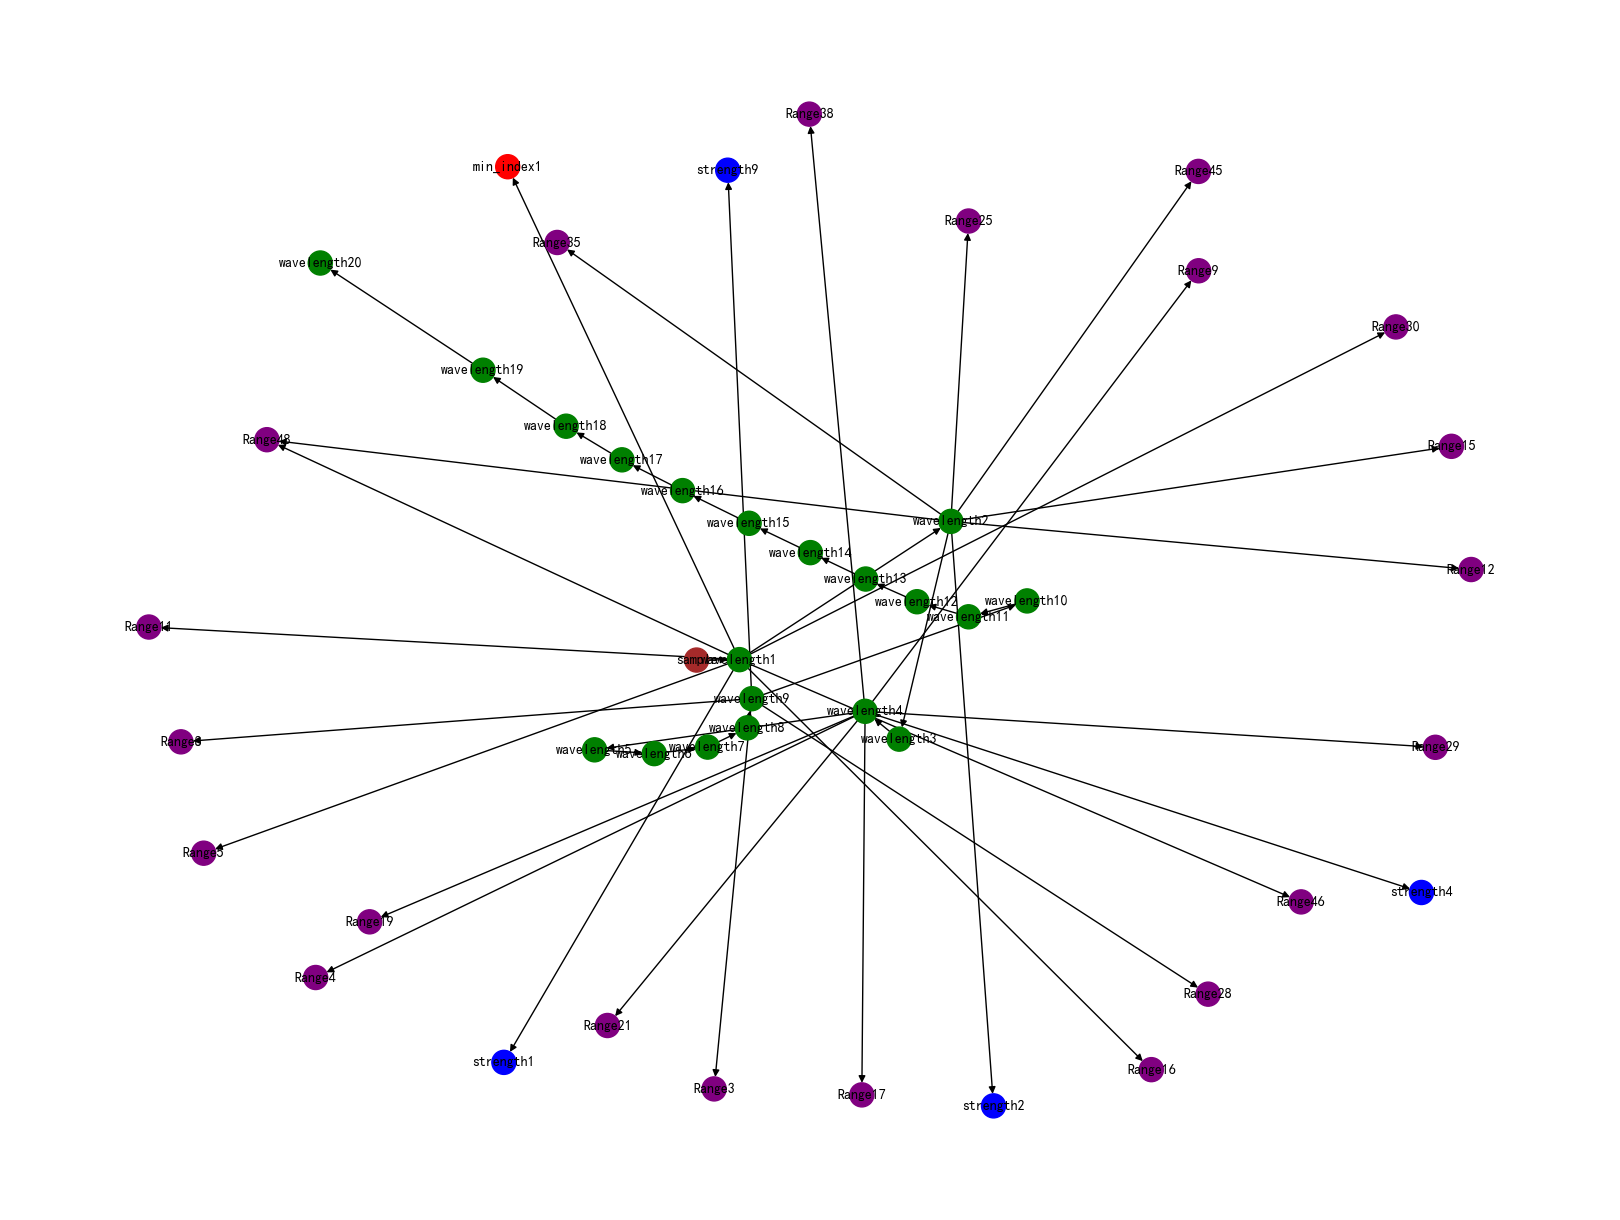

In [25]:
# 扩大后的可视化
#sub_graph = nx.generators.ego_graph(huoqu, 'wavelength1', radius=1,undirected=True)
ppp = huoqu

plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
colors= [ppp.nodes[n]['color'] for n in ppp.nodes()]
# colors = []
# for n in ppp.nodes():
#     try:colors.append(ppp.nodes[n]['color'])
#     except:
#         colors.append('black')
#         print(n)


plt.figure(figsize=(16, 12))
nx.draw(ppp, pos=pos, with_labels=True,font_size=10,node_color=colors)
edge_labels = nx.get_edge_attributes(ppp, 'relatio')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

# 采用大模型将节点信息，边信息转换为文本

## 检测无信息的node，edge

In [26]:
# 对于huoqu2中的所有节点，如果其属性中不存在'raw_text'，则输出该节点名
for node,attr in huoqu2.nodes(data=True):
    if 'raw_text' not in attr.keys():
        print(node)

# 对应huoqu2中的所有边线，如果其属性中不存在'relation'，则输出该边线
for edge1,edge2,attr in huoqu2.edges(data=True):
    if 'relation' not in attr.keys():
        print(edge1,edge2)

wavelength8 wavelength9
wavelength17 wavelength18
wavelength18 wavelength19
wavelength10 wavelength11
wavelength7 wavelength8
wavelength5 wavelength6
wavelength15 wavelength16
wavelength9 wavelength10
wavelength9 strength9
wavelength3 wavelength4
wavelength6 wavelength7
wavelength11 wavelength12
wavelength19 wavelength20
wavelength2 wavelength3
wavelength2 strength2
wavelength14 wavelength15
wavelength4 wavelength5
wavelength4 strength4
wavelength16 wavelength17
wavelength1 wavelength2
wavelength1 strength1
wavelength1 min_index1
wavelength12 wavelength13
wavelength13 wavelength14


In [31]:
# origin_edge_relation = []
# for i in huoqu2.edges(data=True):
#     origin_edge_relation.append(i[:2])

In [32]:
# # 将pyg_data.edge_index转换为相连的节点组形式并保存，即（nodeA，nodeB）
# edge_list = []
# for i in range(pyg_data.edge_index.shape[1]):
#     edge_list.append((pyg_data.node_name[int(pyg_data.edge_index[0][i])],pyg_data.node_name[int(pyg_data.edge_index[1][i])]))
# edge_list

In [33]:
# print(len(edge_list),len(origin_edge_relation))

In [34]:
# # 比较edge_list和origin_edge_relation在每一项上的不同
# a = origin_edge_relation.copy()
# b = edge_list.copy()

# for i in range(len(origin_edge_relation)):
#     # 如果origin_edge_relation[i]在origin_edge_relation中只出现一次，则删除
#     if origin_edge_relation.count(origin_edge_relation[i]) == 1 and origin_edge_relation[i] in edge_list:
#         # 将a中的该元素修改为False
#         a[i] = False
#         # 检索origin_edge_relation[i]出现在b中的位置，并将检索结果中最靠前的索引标记为False，其余不变
#         b[b.index(origin_edge_relation[i])] = False

In [35]:
# # 遍历huoqu2中的所有边线，并保存其存在的属性
# edge_relation = {}
# for edge1,edge2,attr in huoqu2.edges(data=True):
#     #print(edge1,edge2,attr)
#     edge_relation[(edge1,edge2)] = attr

In [27]:
# 先测试在不同的模式中的转换
# 1.从networkx转换为pyg
pyg_data = Merge_information.from_networkx_2_pyg(huoqu2)
pyg_data.keys()

['node_name', 'x', 'edge_index', 'edge_attributes', 'node_attributes']

In [28]:
# 2.从pyg转换为networkx
nx_data = Merge_information.from_pyg_2_networkx(pyg_data)
networkx_graph = nx_data

In [38]:
# # 相关的代码
# networkx_graph = nx.MultiDiGraph()
# # 使用 add_nodes_from 批处理的效率比 add_node 高
# networkx_graph.add_nodes_from([i for i in range(pyg_data.x.shape[0])])

# # 使用 add_edges_from 批处理的效率比 add_edge 高
# edges = np.array(pyg_data.edge_index.T, dtype=int)
# networkx_graph.add_edges_from(edges)
# ## 遍历pyg_data中的node_attrs，给每一个节点添加对应的属性
# for node_index, attr_dict in pyg_data.node_attributes.items():
#     for key,value in attr_dict.items():
#         networkx_graph.nodes()[node_index][key] = value

# # 根据pyg_data.edge_attributes中的信息，给每一个边线添加对应的属性
# for edge_index, attr_dict in pyg_data.edge_attributes.items():
#     for key,value in attr_dict.items():
#         networkx_graph[edge_index[0]][edge_index[1]][0][key] = value

# networkx_graph = nx.relabel_nodes(networkx_graph, pyg_data.node_name)

In [39]:
# # 对比huoqu2和netwrokx的节点是否相同，需要对比节点名称与节点属性
# for node in huoqu2.nodes(data=True):
#     if node[0] not in networkx_graph.nodes():
#         print(node[0])
#     for key,value in node[1].items():
#         if networkx_graph.nodes()[node[0]][key] != value:
#             print(node[0],key)

# # # 反过来比较
# for node in networkx_graph.nodes(data=True):
#     if node[0] not in huoqu2.nodes():
#         print(node[0])
#     for key,value in node[1].items():
#         if huoqu2.nodes()[node[0]][key] != value:
#             print(node[0],key)

In [40]:
# # # 对比huoqu2和netwrokx的边线是否相同，需要对比边线两端的节点与方向，还有边线属性
# for edge in huoqu2.edges(data=True):
#     if edge[:2] not in networkx_graph.edges():
#         print(edge[:2])
#     for key,value in edge[2].items():
#         if networkx_graph[edge[0]][edge[1]][0][key] != value:
#             print(edge[0],edge[1],key)
# # 反过来比较
# for edge in networkx_graph.edges(data=True):
#     if edge[:2] not in huoqu2.edges():
#         print(edge[:2])
#     for key,value in edge[2].items():
#         if huoqu2[edge[0]][edge[1]][0][key] != value:
#             print(edge[0],edge[1],key)

## 构建train，valid，test部分

In [13]:
## 批量测试
# 批量化处理，测试
test_class = Merge_PygDataset(FG_graph,Spectrum_graph['(C6H4)2'])
connected_dictionary = test_class.preprocess()
all_Table,isexist,score_dict = test_class.Negative_relevant_information(is_print=False)
OP = test_class.construct_graph(connected_dictionary,all_Table,is_print=False)

In [20]:
fin = test_class.subgraph_extraction(hop=1)

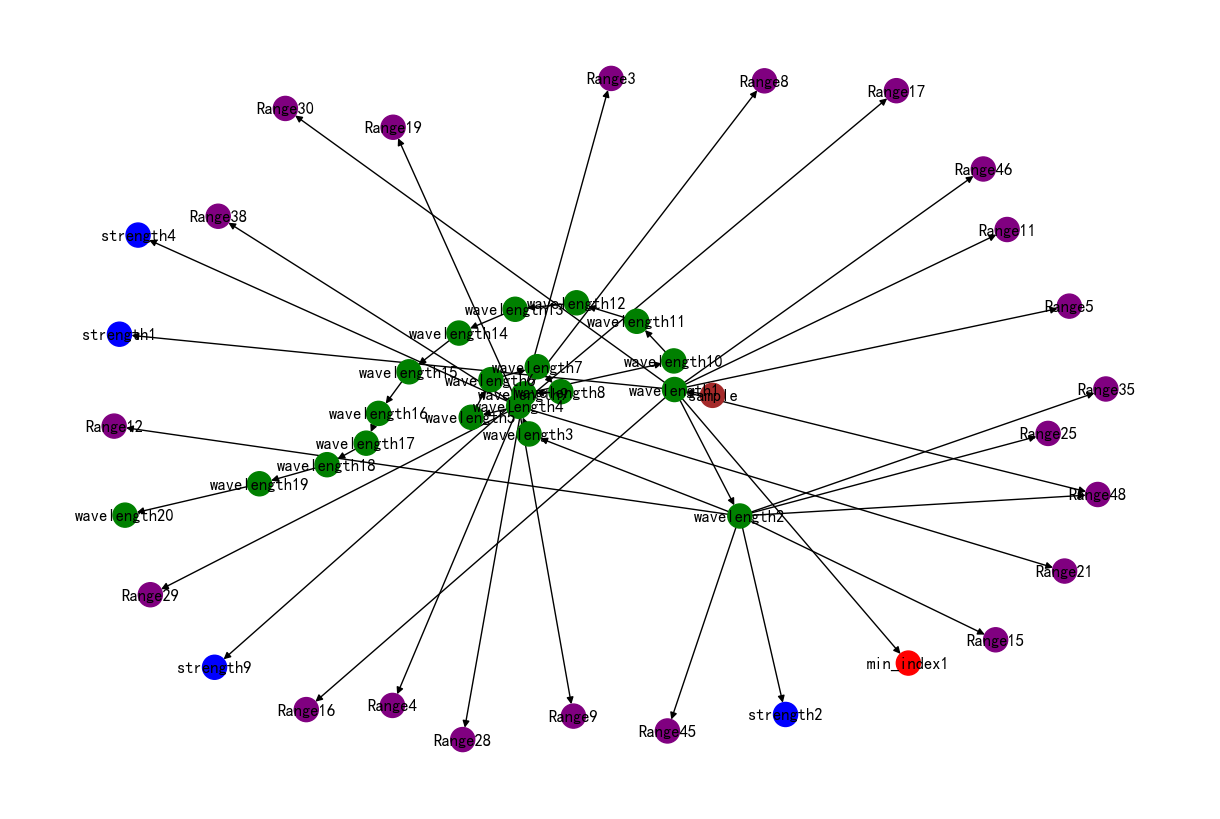

In [24]:
test_class.graph_visualisation(fin)

## 大模型编码

In [29]:
# 0. Check GPU setting.
device, gpu_ids = utils.get_available_devices()
gpu_size = len(gpu_ids)
gpu_size

1

In [30]:
# 转换为用于训练的格式pyg
MP = Merge_PygDataset(FG_graph,Spectrum_graph['(C6H4)2'])
MP.GP.merge_graph = huoqu2
# 将huoqu2转换为pyg格式
preprocess_map = MP.GP.from_networkx_2_pyg(MP.GP.merge_graph)

In [32]:
# 初始化编码器
# 可选配置 - LLM_DIM_DICT = {"ST": 768, "BERT": 768, "e5": 1024, "llama2_7b": 4096, "llama2_13b": 5120}
from Models.LLM.LLM_Encoder import SentenceEncoder
encoder = SentenceEncoder('ST',
                          batch_size = 1
                          )

In [33]:
# 获取preprocess_map中的数据
attribute = preprocess_map.node_attributes.copy()
label_name = ['Hydrocarbons','GroupsContainingBoron','GroupsContainingMetals','GroupsContainingPhosphorus','GroupsContainingHalogen','GroupsContainingNitrogen','GroupsContainingOxygen','GroupsContainingSulfur']
nx_z = pyg.utils.to_networkx(preprocess_map,to_undirected=False,to_multi=True)
edge_index = torch.tensor(list(nx_z.edges())).T
print(edge_index.size())
data_dict = preprocess_map.to_dict()  # 将原始数据转换为字典
data_dict['edge_index'] == edge_index
new_data = pyg.data.data.Data(**data_dict)
category_desc = pd.read_csv(
        os.path.join(r'G:\Research\Paper4-Code\2024_5_13\Log', "categories.csv"), 
                     sep=","
    ).values
ordered_desc = []
for i, label in enumerate(label_name):
    true_ind = label == category_desc[:, 0]
    ordered_desc.append((label, category_desc[:, 1][true_ind]))
# 这是用来描述每一个标签的文本信息

torch.Size([2, 111])


In [34]:
clean_text = [attribute[i]['raw_text'] for i in attribute]
label_text = [
    "prompt node. literature category and description: "
    + desc[0]
    + "."
    + desc[1][0]
    for desc in ordered_desc
]
edge_label_text = edge_label_text = [  # 这里仅做占位
    "prompt node. two node has link",
    "prompt node. two node don't have link",
]

logic_label_text = get_logic_label(ordered_desc)

#edge_text = [
#    "feature edge. connected papers are cited together by other papers."
#]

edge_text = preprocess_map.edge_attributes.copy()  # 边的文本信息

noi_node_edge_text = [   # 这是边预测任务：“一起被引用的论文的链接预测”
    "prompt node. link prediction on the papers that are cited together"
]
noi_node_text = [   # 这是节点预测任务，之后可能尝试改成graph预测更好一点？
    "prompt node. node classification on the sample's category based on spectral information and knowledge graph"
]
prompt_edge_text = ["prompt edge", "prompt edge. edge for query graph that is our target",
                    "prompt edge. edge for support graph that is an example"]

In [35]:
# 边信息
preprocess_map.edge_attributes

{(1, 9): {},
 (2, 4): {},
 (4, 14): {},
 (5, 13): {},
 (6, 1): {},
 (7, 12): {},
 (8, 18): {},
 (9, 5): {},
 (9, 11): {},
 (9,
  25): {'relation': 'The absorption peaks present at this wavelength node may correspond to this characteristic interval.'},
 (9,
  26): {'relation': 'The absorption peaks present at this wavelength node may correspond to this characteristic interval.'},
 (9,
  27): {'relation': 'The absorption peaks present at this wavelength node may correspond to this characteristic interval.'},
 (10, 17): {},
 (12, 6): {},
 (13, 22): {},
 (14, 24): {},
 (15, 10): {},
 (15, 0): {},
 (15,
  28): {'relation': 'The absorption peaks present at this wavelength node may correspond to this characteristic interval.'},
 (15,
  29): {'relation': 'The absorption peaks present at this wavelength node may correspond to this characteristic interval.'},
 (15,
  30): {'relation': 'The absorption peaks present at this wavelength node may correspond to this characteristic interval.'},
 (15,
 

In [36]:
# 分类标签的描述
label_text

['prompt node. literature category and description: Hydrocarbons.The "Hydrocarbons" category refers to a class of organic compounds composed solely of hydrogen and carbon atoms. This category includes a wide range of substances such as alkanes, alkenes, and alkynes. Alkanes are characterized by single bonds between carbon atoms and a full complement of hydrogen atoms, examples being methane (CH4) and ethane (C2H6). Alkenes contain at least one carbon-carbon double bond, while alkynes possess carbon-carbon triple bonds. These compounds are the primary constituents of petroleum and natural gas, serving as crucial raw materials in the chemical industry for the production of plastics, rubbers, fuels, and various chemicals. In environmental science, hydrocarbons are also components of air pollutants, such as those found in vehicle exhaust, which contribute to the depletion of the ozone layer. In the energy sector, the extraction, processing, and utilization of hydrocarbons are central issue

In [37]:
# data_list:训练数据本身，texts:训练数据中的文本信息，side_data:任务的说明信息以及标签获取的索引
data_list, texts, side_data = (
        [new_data],
        [
            clean_text, # node_text_feat
            edge_text,  # edge_text_feat
            noi_node_text + noi_node_edge_text, # noi_node_text_feat
            label_text + edge_label_text + logic_label_text, # class_node_text_feat
            prompt_edge_text, # prompt_edge_text_feat
        ],
        {"e2e_node": {"noi_node_text_feat": ["noi_node_text_feat", [0]],
                      "class_node_text_feat": ["class_node_text_feat", torch.arange(len(label_text))],
                      "prompt_edge_text_feat": ["prompt_edge_text_feat", [0]]},
         "e2e_link": {"noi_node_text_feat": ["noi_node_text_feat", [1]],
                      "class_node_text_feat": ["class_node_text_feat",
                                               torch.arange(len(label_text), len(label_text) + len(edge_label_text))],
                      "prompt_edge_text_feat": ["prompt_edge_text_feat", [0]]},
         "lr_node": {"noi_node_text_feat": ["noi_node_text_feat", [0]],
                     "class_node_text_feat": ["class_node_text_feat", torch.arange(len(label_text))],
                     "prompt_edge_text_feat": ["prompt_edge_text_feat", [0, 1, 2]]},
         "logic_e2e": {"noi_node_text_feat": ["noi_node_text_feat", [0]],
                       "class_node_text_feat": ["class_node_text_feat",
                                                torch.arange(len(label_text) + len(edge_label_text),
                                                             len(label_text) + len(edge_label_text) + len(
                                                                 logic_label_text))],
                       "prompt_edge_text_feat": ["prompt_edge_text_feat", [0]]},
         }
    )


In [ ]:
# 保存预处理后的数据
# torch.save(texts, self.processed_paths[1])  # 这里是节点，边等部分，格式化后的文本信息 'cache_data\\Cora\\ST\\processed\\texts.pkl'
# if side_data is not None:
#     torch.save(side_data, self.processed_paths[2])  # 这里是不同任务的Config信息 'cache_data\\Cora\\ST\\processed\\data.pt'
# else:
#     torch.save("No side data", self.processed_paths[2])


In [38]:
def add_raw_texts(self, data_list, texts):
    data_list[0].node_text_feat = np.array(texts[0])
    data_list[0].edge_text_feat = np.array(texts[1])
    data_list[0].noi_node_text_feat = np.array(texts[2])
    data_list[0].class_node_text_feat = np.array(texts[3])
    data_list[0].prompt_edge_text_feat = np.array(texts[4])
    return self.collate(data_list)
def text2feature(texts,encoder):
    try: 
        judge = isinstance(texts[0], str)
        if judge:
            return data2vec(encoder,texts)
    except: 
        judge = isinstance(texts, dict)
        if judge:
            output_data = {key:{} for key,value in preprocess_map.edge_attributes.items()}
            collect_edge_name = []
            collect_edge_data = []
            for key, value in texts.items():
                if value:
                    for name,attr in value.items():
                        collect_edge_name.append(f'{key}' + '_' + name)
                        collect_edge_data.append(attr)
                        #collect_data[name] = data2vec(encoder,attr)
            encode_data = data2vec(encoder,collect_edge_data)
            print(np.array(collect_edge_name).shape)
            for i in range(len(collect_edge_name)):
                    output_data[eval(collect_edge_name[i].split('_')[0])][collect_edge_name[i].split('_')[1]] = encode_data[i]
                    #output_data[key] = collect_data
            return output_data
    return [text2feature(t,encoder) for t in texts]
def data2vec(encoder, data: list[str]) -> torch.Tensor:
    r"""
    Encode a list of string to a len(data)-by-d matrix, where d is the output dimension of the LLM.
    """
    if encoder is None:
        raise NotImplementedError("LLM encoder is not defined")
    if data is None:
        return None
    embeddings = encoder.encode(data).cpu().numpy()
    return embeddings

In [39]:
load_texts = False
if load_texts:
    data, slices = add_raw_texts(data_list, texts)
else:
    if encoder.model is None:
        encoder.get_model()
    texts_emb = text2feature(texts,encoder=encoder)
    #data, slices = self.add_text_emb(data_list, texts_emb)

print("Saving...")
#torch.save((data, slices, ), self.processed_paths[0], pickle_protocol=4)

Batches:   0%|          | 0/93 [00:00<?, ?it/s]

Batches:   0%|          | 0/91 [00:00<?, ?it/s]

(91,)


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/138 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Saving...


In [62]:
#texts_emb[1][(3,25)]['relation'].shape

In [40]:
if encoder is not None:
    encoder.flush_model()

In [85]:
# p=0
# collect = []
# for key,value in preprocess_map.edge_attributes.items():
#     if value:
#         if len(value.keys())>1:
#             print(key)
#             print(preprocess_map.edge_attributes[key])


In [86]:
# collect_edge_name = []
# collect_edge_data = []
# for key, value in preprocess_map.edge_attributes.items():
#         if value:
#             for name,attr in value.items():
#                 collect_edge_name.append(f'{key}' + '_' + name)
#                 collect_edge_data.append(attr)
#                 #collect_data[name] = data2vec(encoder,attr)
    
# print(np.array(collect_edge_name).shape)

# 训练

In [ ]:
# 1.以上只处理了单个，需要将全部样本打包为训练集，测试集
# 2.构造训练模型

## 加载配置文件

In [3]:
configs = []
configs.append(
    utils.load_yaml(
        os.path.join(
            #os.path.dirname(__file__), "configs", "default_config.yaml"
            './', "Configs", "default_config.yaml"
        )
    )
)

In [4]:
# 可选的配置更新
# 添加新的config
override_config = utils.load_yaml('./Configs/Override/e2e_all_config.yaml')
configs.append(override_config)

In [5]:
# 更新配置
mod_params = utils.combine_dict(*configs)
#mod_params = merge_mod(mod_params, params.opts)
mod_params = utils.merge_mod(mod_params, [])

In [6]:
# 信息存储路径
curtime = datetime.now()
exp_name = str(curtime).replace(" ", "_")
exp_name = exp_name.replace(":", "_")
exp_name = exp_name.replace(".", "_")
exp_name = exp_name.split("_")[0]
exp_dir = os.path.join("./saved_exp", exp_name)
if not os.path.exists(exp_dir):
    os.makedirs(exp_dir)

In [7]:
# 保存并转换配置文件
with open(os.path.join(exp_dir, "command"), "w") as f:  # 保存配置文件
    yaml.dump(mod_params, f)
mod_params["exp_dir"] = exp_dir
params = SimpleNamespace(**mod_params)
utils.set_random_seed(params.seed)
torch.set_float32_matmul_precision("high")
params.log_project = "full_cdm"

params.exp_name += f"_{params.llm_name}_ofa1"

## 加载模型

In [10]:
# 补充一个config提供参数

out_dim = params.emb_dim + (params.rwpe if params.rwpe is not None else 0)

gnn = PyGRGCNEdge(
    params.num_layers,
    5,
    out_dim,
    out_dim,
    drop_ratio=params.dropout,
    JK=params.JK,
)

bin_model = BinGraphAttModel if params.JK == "none" else BinGraphModel
model = bin_model(model=gnn, llm_name=params.llm_name, outdim=out_dim, task_dim=1,
                    add_rwpe=params.rwpe, dropout=params.dropout)

# Construct datasets and lightning datamodule.

In [14]:
if hasattr(params, "d_multiple"):
    if isinstance(params.d_multiple, str):
        data_multiple = [float(a) for a in params.d_multiple.split(",")]
    else:
        data_multiple = params.d_multiple
else:
    data_multiple = [1]

if hasattr(params, "d_min_ratio"):
    if isinstance(params.d_min_ratio, str):
        min_ratio = [float(a) for a in params.d_min_ratio.split(",")]
    else:
        min_ratio = params.d_min_ratio
else:
    min_ratio = [1]

In [ ]:
train_data = tasks.make_train_data(data_multiple, min_ratio, data_val_index=val_task_index_lst)
text_dataset = tasks.make_full_dm_list(
    data_multiple, min_ratio, train_data
)
params.datamodule = DataModule(
    text_dataset, gpu_size=gpu_size, num_workers=params.num_workers
)
